In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")


All libraries imported successfully!


In [6]:
df = pd.read_csv('retail_sales_cleaned.csv')
print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (1000, 10)


In [8]:
df.head(10)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month
0,1,24-11-2023,CUST001,Male,34,Beauty,3,50,150,Nov
1,2,27-02-2023,CUST002,Female,26,Clothing,2,500,1000,Feb
2,3,13-01-2023,CUST003,Male,50,Electronics,1,30,30,Jan
3,4,21-05-2023,CUST004,Male,37,Clothing,1,500,500,May
4,5,06-05-2023,CUST005,Male,30,Beauty,2,50,100,May
5,6,25-04-2023,CUST006,Female,45,Beauty,1,30,30,Apr
6,7,13-03-2023,CUST007,Male,46,Clothing,2,25,50,Mar
7,8,22-02-2023,CUST008,Male,30,Electronics,4,25,100,Feb
8,9,13-12-2023,CUST009,Male,63,Electronics,2,300,600,Dec
9,10,07-10-2023,CUST010,Female,52,Clothing,4,50,200,Oct


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
 9   Month             1000 non-null   str  
dtypes: int64(5), str(5)
memory usage: 78.3 KB


In [12]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
Month               0
dtype: int64

In [14]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [16]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [18]:
# Set style for all plots
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)

print("Plot style set successfully!")

Plot style set successfully!


C:\Users\PC\AppData\Local\Temp\ipykernel_2168\4238712991.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Product Category', y='Total Amount', data=category_sales, palette='Blues_d')


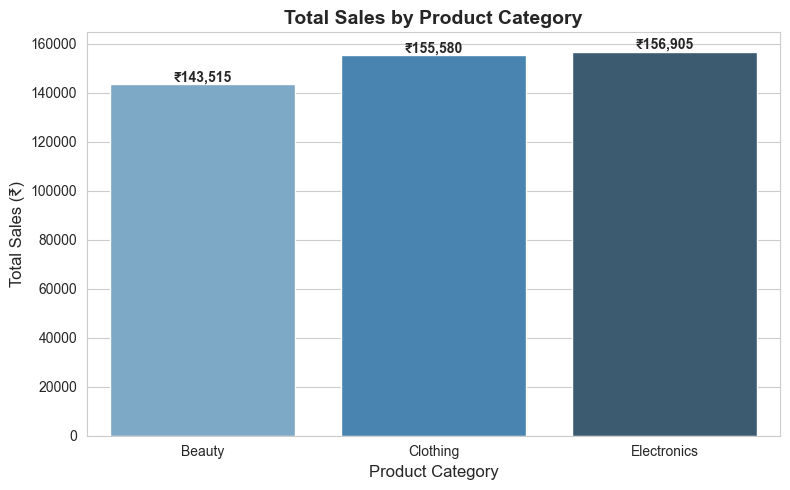

Plot 1 done!


In [20]:
plt.figure(figsize=(8, 5))
category_sales = df.groupby('Product Category')['Total Amount'].sum().reset_index()
sns.barplot(x='Product Category', y='Total Amount', data=category_sales, palette='Blues_d')
plt.title('Total Sales by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Sales (₹)', fontsize=12)
for i, v in enumerate(category_sales['Total Amount']):
    plt.text(i, v + 1000, f'₹{v:,.0f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('plot1_category_sales.png', dpi=150)
plt.show()
print("Plot 1 done!")

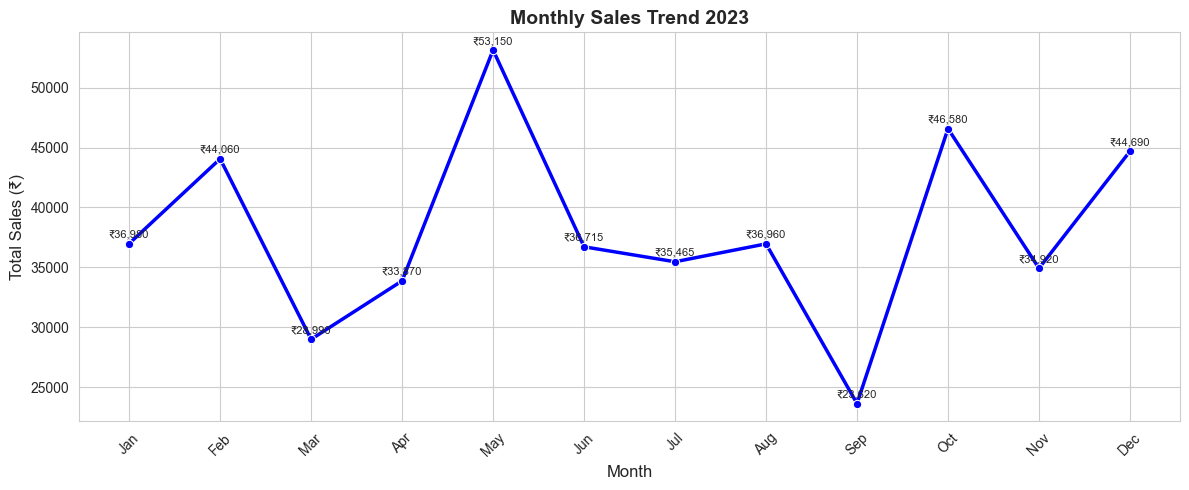

Plot 2 done!


In [22]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
monthly_sales = df.groupby('Month')['Total Amount'].sum().reindex(month_order).reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(x='Month', y='Total Amount', data=monthly_sales, 
             marker='o', linewidth=2.5, color='blue')
plt.title('Monthly Sales Trend 2023', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales (₹)', fontsize=12)
plt.xticks(rotation=45)
for i, row in monthly_sales.iterrows():
    plt.text(i, row['Total Amount'] + 500, f'₹{row["Total Amount"]:,.0f}', 
             ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('plot2_monthly_trend.png', dpi=150)
plt.show()
print("Plot 2 done!")

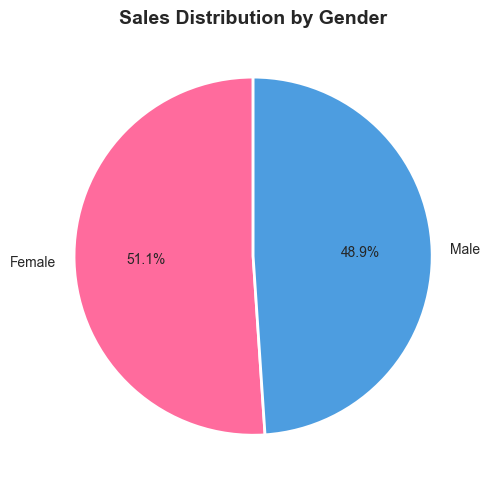

Plot 3 done!


In [24]:
plt.figure(figsize=(7, 5))
gender_sales = df.groupby('Gender')['Total Amount'].sum().reset_index()
colors = ['#FF6B9D', '#4D9DE0']
plt.pie(gender_sales['Total Amount'], labels=gender_sales['Gender'], 
        autopct='%1.1f%%', colors=colors, startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Sales Distribution by Gender', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot3_gender_sales.png', dpi=150)
plt.show()
print("Plot 3 done!")

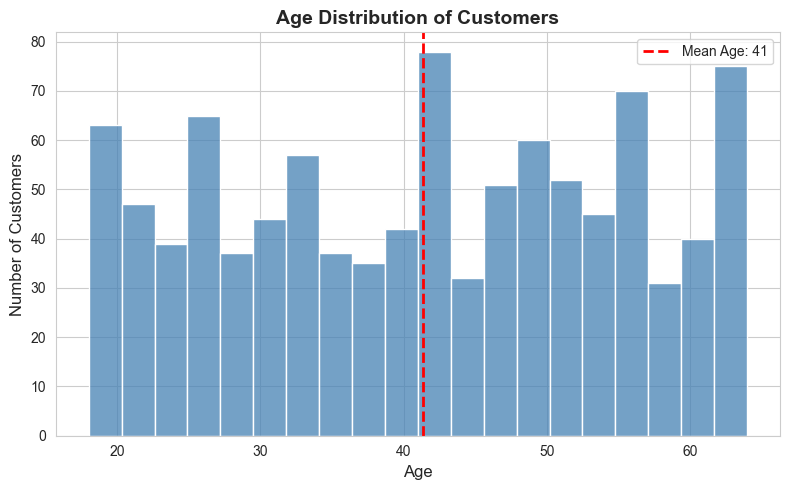

Plot 4 done!


In [26]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=20, color='steelblue', edgecolor='white')
plt.title('Age Distribution of Customers', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.axvline(df['Age'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Mean Age: {df["Age"].mean():.0f}')
plt.legend()
plt.tight_layout()
plt.savefig('plot4_age_distribution.png', dpi=150)
plt.show()
print("Plot 4 done!")

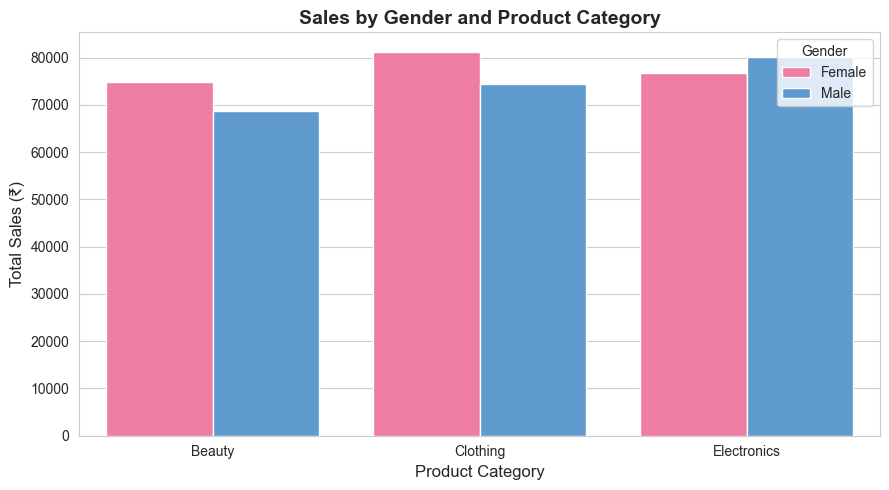

Plot 5 done!


In [28]:
plt.figure(figsize=(9, 5))
gender_category = df.groupby(['Product Category', 'Gender'])['Total Amount'].sum().reset_index()
sns.barplot(x='Product Category', y='Total Amount', hue='Gender', 
            data=gender_category, palette=['#FF6B9D', '#4D9DE0'])
plt.title('Sales by Gender and Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Sales (₹)', fontsize=12)
plt.legend(title='Gender')
plt.tight_layout()
plt.savefig('plot5_gender_category.png', dpi=150)
plt.show()
print("Plot 5 done!")

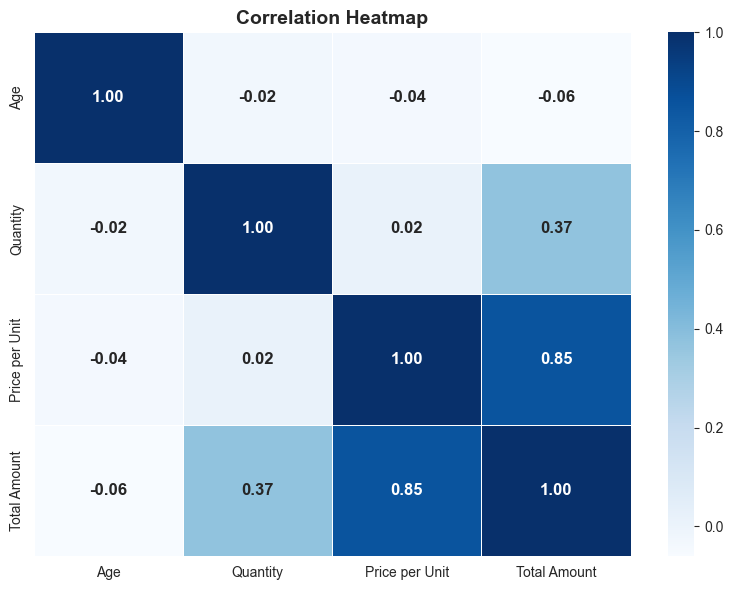

Plot 6 done!


In [30]:
plt.figure(figsize=(8, 6))
numeric_cols = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']]
correlation = numeric_cols.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 12, 'weight': 'bold'})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot6_correlation_heatmap.png', dpi=150)
plt.show()
print("Plot 6 done!")


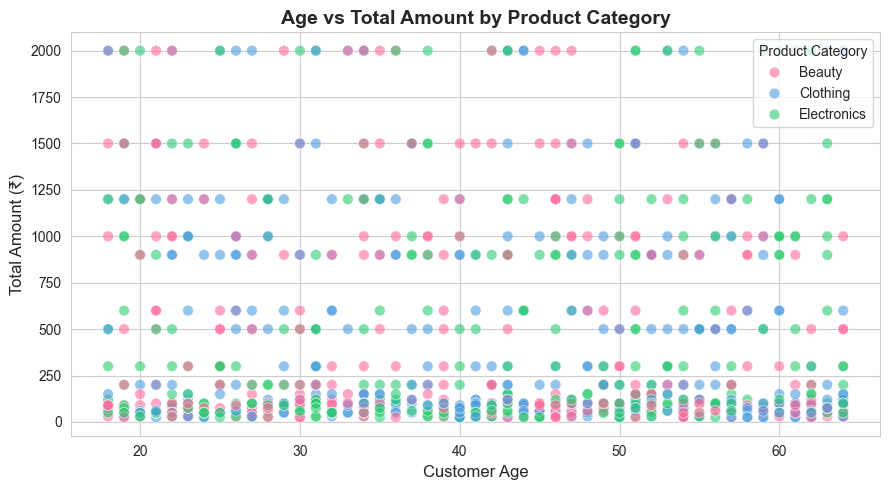

Plot 7 done!


In [32]:
plt.figure(figsize=(9, 5))
sns.scatterplot(x='Age', y='Total Amount', data=df, 
                hue='Product Category', 
                palette=['#FF6B9D', '#4D9DE0', '#2ECC71'],
                alpha=0.6, s=60)
plt.title('Age vs Total Amount by Product Category', 
          fontsize=14, fontweight='bold')
plt.xlabel('Customer Age', fontsize=12)
plt.ylabel('Total Amount (₹)', fontsize=12)
plt.legend(title='Product Category')
plt.tight_layout()
plt.savefig('plot7_age_vs_amount.png', dpi=150)
plt.show()
print("Plot 7 done!")

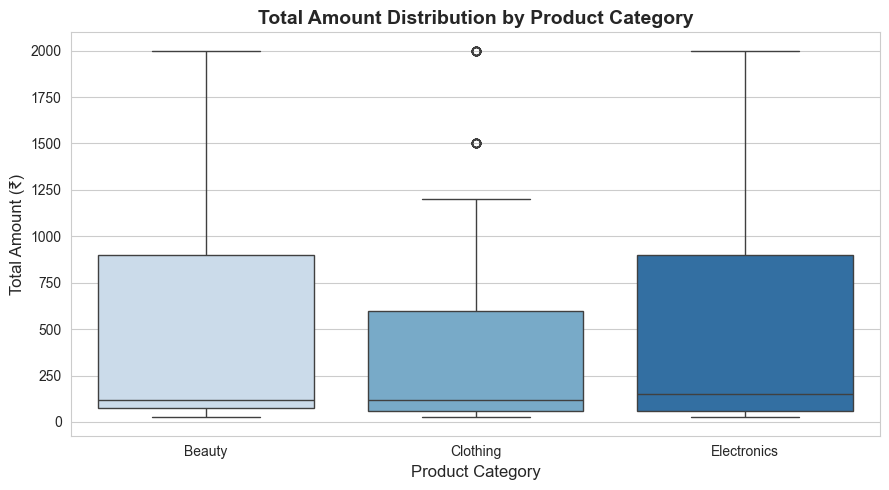

Plot 8 done!


In [34]:
plt.figure(figsize=(9, 5))
sns.boxplot(x='Product Category', y='Total Amount', 
            data=df, palette='Blues',
            hue='Product Category', legend=False)
plt.title('Total Amount Distribution by Product Category', 
          fontsize=14, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Amount (₹)', fontsize=12)
plt.tight_layout()
plt.savefig('plot8_boxplot.png', dpi=150)
plt.show()
print("Plot 8 done!")


In [36]:
print("=" * 50)
print("RETAIL SALES - KEY STATISTICS")
print("=" * 50)

print("\n1. SALES BY PRODUCT CATEGORY:")
print(df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False))

print("\n2. SALES BY GENDER:")
print(df.groupby('Gender')['Total Amount'].sum())

print("\n3. AVERAGE SPENDING BY GENDER:")
print(df.groupby('Gender')['Total Amount'].mean().round(2))

print("\n4. TOP 3 HIGHEST SALES MONTHS:")
print(df.groupby('Month')['Total Amount'].sum().sort_values(ascending=False).head(3))

print("\n5. AVERAGE AGE BY PRODUCT CATEGORY:")
print(df.groupby('Product Category')['Age'].mean().round(1))

print("\n6. MOST POPULAR CATEGORY BY QUANTITY:")
print(df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False))


RETAIL SALES - KEY STATISTICS

1. SALES BY PRODUCT CATEGORY:
Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

2. SALES BY GENDER:
Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64

3. AVERAGE SPENDING BY GENDER:
Gender
Female    456.55
Male      455.43
Name: Total Amount, dtype: float64

4. TOP 3 HIGHEST SALES MONTHS:
Month
May    53150
Oct    46580
Dec    44690
Name: Total Amount, dtype: int64

5. AVERAGE AGE BY PRODUCT CATEGORY:
Product Category
Beauty         40.4
Clothing       41.9
Electronics    41.7
Name: Age, dtype: float64

6. MOST POPULAR CATEGORY BY QUANTITY:
Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64


In [37]:
print("=" * 50)
print("EDA COMPLETED SUCCESSFULLY!")
print("=" * 50)
print(f"\nTotal Records Analysed: {len(df)}")
print(f"Total Columns: {len(df.columns)}")
print(f"Total Sales: ₹{df['Total Amount'].sum():,.0f}")
print(f"Average Order Value: ₹{df['Total Amount'].mean():,.0f}")
print(f"Best Category: {df.groupby('Product Category')['Total Amount'].sum().idxmax()}")
print(f"Best Month: {df.groupby('Month')['Total Amount'].sum().idxmax()}")
print(f"Top Gender: {df.groupby('Gender')['Total Amount'].sum().idxmax()}")
print("\nCharts saved:")
charts = ['plot1_category_sales.png', 'plot2_monthly_trend.png',
          'plot3_gender_sales.png', 'plot4_age_distribution.png',
          'plot5_gender_category.png', 'plot6_correlation_heatmap.png',
          'plot7_age_vs_amount.png', 'plot8_boxplot.png']
for chart in charts:
    print(f"  ✓ {chart}")

EDA COMPLETED SUCCESSFULLY!

Total Records Analysed: 1000
Total Columns: 10
Total Sales: ₹456,000
Average Order Value: ₹456
Best Category: Electronics
Best Month: May
Top Gender: Female

Charts saved:
  ✓ plot1_category_sales.png
  ✓ plot2_monthly_trend.png
  ✓ plot3_gender_sales.png
  ✓ plot4_age_distribution.png
  ✓ plot5_gender_category.png
  ✓ plot6_correlation_heatmap.png
  ✓ plot7_age_vs_amount.png
  ✓ plot8_boxplot.png
